# Basic setup

In [ ]:
from google.colab import drive
from google.colab import files
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import ks_2samp
import time
import numpy as np
from scipy.stats import rankdata
from __future__ import annotations
import os
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform

In [ ]:
drive.mount('/content/drive')

train_path = '/content/drive/MyDrive/Colab Notebooks/QRT/train.csv'
test_path = '/content/drive/MyDrive/Colab Notebooks/QRT/test.csv'
#feature_engineered_train_path = "/content/drive/MyDrive/Colab Notebooks/QRT/train_full_feat_df.parquet"
train_diagnostic_path = '/content/drive/MyDrive/Colab Notebooks/QRT/train_prediction_diagnostics.parquet'
test_diagnostic_path = '/content/drive/MyDrive/Colab Notebooks/QRT/test_prediction_diagnostics.parquet'
feature_importance_full = '/content/drive/MyDrive/Colab Notebooks/QRT/feature_importance_raw.parquet'
feature_importance_summary = '/content/drive/MyDrive/Colab Notebooks/QRT/feature_importance_summary.parquet'

Mounted at /content/drive


In [ ]:
warnings.filterwarnings("ignore")

In [ ]:
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
train_diagnostic_df = pd.read_parquet(train_diagnostic_path)
test_diagnostic_df = pd.read_parquet(test_diagnostic_path)
feature_importance_full = pd.read_parquet(feature_importance_full)
feature_importance_summary = pd.read_parquet(feature_importance_summary)
#train_full_feat_df=pd.read_parquet(feature_engineered_train_path)

# Feature engineering

In [ ]:
# def make_regime_bucket_map(df, target_col="TARGET", lo=0.45, hi=0.55):
#     win_rates = df.groupby("ALLOCATION")[target_col].apply(lambda x: (x > 0).mean())

#     def assign(rate):
#         if rate < lo:
#             return 0   # short / negative allocation regime
#         elif rate > hi:
#             return 2   # long / positive allocation regime
#         else:
#             return 1   # neutral / noisy regime

#     return win_rates.apply(assign)

In [ ]:
# RET_COLS = [f"RET_{i}" for i in range(1, 21)]
# VOL_COLS = [f"SIGNED_VOLUME_{i}" for i in range(2, 21)]  # drop SIGNED_VOLUME_1


# def vec_stats(M, prefix):
#     feats = {}
#     N, T = M.shape

#     ups = np.where(M > 0, M, 0).mean(axis=1)
#     downs = np.where(M < 0, np.abs(M), 0).mean(axis=1)
#     feats[f"{prefix}_rsi"] = ups / (ups + downs + 1e-9)

#     feats[f"{prefix}_mean"] = np.nanmean(M, axis=1)
#     feats[f"{prefix}_std"] = np.nanstd(M, axis=1)
#     feats[f"{prefix}_min"] = np.nanmin(M, axis=1)
#     feats[f"{prefix}_max"] = np.nanmax(M, axis=1)
#     feats[f"{prefix}_range"] = feats[f"{prefix}_max"] - feats[f"{prefix}_min"]

#     feats[f"{prefix}_sharpe"] = np.where(
#         feats[f"{prefix}_std"] > 1e-9,
#         feats[f"{prefix}_mean"] / feats[f"{prefix}_std"],
#         0.0,
#     )

#     feats[f"{prefix}_pct_pos"] = np.nanmean(M > 0, axis=1)

#     feats[f"{prefix}_last1"] = M[:, -1]
#     feats[f"{prefix}_last3"] = np.nanmean(M[:, -3:], axis=1)
#     feats[f"{prefix}_last5"] = np.nanmean(M[:, -5:], axis=1)
#     feats[f"{prefix}_last10"] = np.nanmean(M[:, -10:], axis=1)
#     feats[f"{prefix}_first5"] = np.nanmean(M[:, :5], axis=1)

#     feats[f"{prefix}_mom_5_20"] = feats[f"{prefix}_last5"] - feats[f"{prefix}_first5"]
#     feats[f"{prefix}_mom_3_10"] = np.nanmean(M[:, -3:], axis=1) - np.nanmean(M[:, 7:17], axis=1)

#     feats[f"{prefix}_vol5"] = np.nanstd(M[:, -5:], axis=1)
#     feats[f"{prefix}_vol10"] = np.nanstd(M[:, -10:], axis=1)
#     feats[f"{prefix}_vol_ratio"] = np.where(
#         feats[f"{prefix}_vol10"] > 1e-9,
#         feats[f"{prefix}_vol5"] / feats[f"{prefix}_vol10"],
#         1.0,
#     )

#     x = np.arange(T, dtype=np.float32)
#     xm = x.mean()
#     xv = ((x - xm) ** 2).sum()
#     feats[f"{prefix}_trend"] = np.where(
#         xv > 0,
#         ((M - np.nanmean(M, axis=1, keepdims=True)) * (x - xm)).sum(axis=1) / xv,
#         0.0,
#     )

#     mu = np.nanmean(M, axis=1, keepdims=True)
#     std = np.nanstd(M, axis=1, keepdims=True) + 1e-9
#     z = (M - mu) / std
#     feats[f"{prefix}_skew"] = np.nanmean(z ** 3, axis=1)
#     feats[f"{prefix}_kurt"] = np.nanmean(z ** 4, axis=1) - 3.0

#     M0 = M[:, :-1] - np.nanmean(M[:, :-1], axis=1, keepdims=True)
#     M1 = M[:, 1:] - np.nanmean(M[:, 1:], axis=1, keepdims=True)
#     num = np.nansum(M0 * M1, axis=1)
#     den = np.sqrt(np.nansum(M0**2, axis=1) * np.nansum(M1**2, axis=1))
#     feats[f"{prefix}_autocorr1"] = np.where(den > 1e-9, num / den, 0.0)

#     s5 = np.sign(M[:, -5:])
#     feats[f"{prefix}_streak5"] = (
#         (s5 > 0).all(axis=1).astype(np.float32)
#         - (s5 < 0).all(axis=1).astype(np.float32)
#     )

#     return feats

# def compute_alloc_stats(df, target_col='TARGET'):
#     # 1. Isolate the 20 daily return columns
#     ret_cols = [f'RET_{i}' for i in range(1, 21)]

#     # 2. Calculate row-by-row moments horizontally across the 20 days
#     df['_temp_row_mean'] = df[ret_cols].mean(axis=1)
#     df['_temp_row_vol']  = df[ret_cols].std(axis=1)
#     df['_temp_row_skew'] = df[ret_cols].skew(axis=1)
#     df['_temp_row_kurt'] = df[ret_cols].kurt(axis=1)
#     df['_temp_row_sharpe'] = df['_temp_row_mean'] / (df['_temp_row_vol'] + 1e-8)

#     # 3. Create the indicator for the positive sign binary target
#     df['_is_positive'] = (df[target_col] > 0).astype(float)

#     # 4. Single-pass aggregation by ALLOCATION (Using function pointers for kurtosis)
#     grouped = df.groupby("ALLOCATION").agg(
#         # Target Moments
#         alloc_win_rate=('_is_positive', 'mean'),
#         alloc_mean_ret=(target_col, 'mean'),
#         alloc_vol=(target_col, 'std'),
#         alloc_skew=(target_col, 'skew'),
#         alloc_kurt=(target_col, pd.Series.kurt),  # FIXED: Pass the actual function instead of the string 'kurt'

#         # Aggregated 20-Day Feature Moments
#         alloc_avg_row_mean=('_temp_row_mean', 'mean'),
#         alloc_avg_row_vol=('_temp_row_vol', 'mean'),
#         alloc_avg_row_skew=('_temp_row_skew', 'mean'),
#         alloc_avg_row_kurt=('_temp_row_kurt', 'mean'), # FIXED: '_temp_row_kurt' is already aggregated horizontally, so we take the 'mean' here
#         alloc_avg_row_sharpe=('_temp_row_sharpe', 'mean')
#     )

#     # 5. Vectorized calculation for target Sharpe ratio
#     grouped['alloc_sharpe'] = grouped['alloc_mean_ret'] / (grouped['alloc_vol'] + 1e-8)

#     # 6. Clean up all temporary columns from source dataframe
#     temp_cols = ['_temp_row_mean', '_temp_row_vol', '_temp_row_skew',
#                  '_temp_row_kurt', '_temp_row_sharpe', '_is_positive']
#     df.drop(columns=temp_cols, inplace=True, errors='ignore')

#     # 7. Convert columns into a dictionary of pandas Series
#     return {
#         "alloc_win_rate": grouped["alloc_win_rate"],
#         "alloc_mean_ret": grouped["alloc_mean_ret"],
#         "alloc_vol": grouped["alloc_vol"],
#         "alloc_skew": grouped["alloc_skew"],
#         "alloc_kurt": grouped["alloc_kurt"],
#         "alloc_sharpe": grouped["alloc_sharpe"],

#         "alloc_avg_row_mean": grouped["alloc_avg_row_mean"],
#         "alloc_avg_row_vol": grouped["alloc_avg_row_vol"],
#         "alloc_avg_row_skew": grouped["alloc_avg_row_skew"],
#         "alloc_avg_row_kurt": grouped["alloc_avg_row_kurt"],
#         "alloc_avg_row_sharpe": grouped["alloc_avg_row_sharpe"]
#     }



# CS_BASE_COLS = [
#     "ret_mean", "ret_std", "ret_min", "ret_max", "ret_range", "ret_sharpe",
#     "ret_pct_pos", "ret_last1", "ret_last3", "ret_last5", "ret_last10",
#     "ret_mom_5_20", "ret_mom_3_10", "ret_vol5", "ret_vol10", "ret_vol_ratio",
#     "ret_trend", "ret_skew", "ret_kurt", "ret_autocorr1", "ret_streak5",
#     "vol_mean", "vol_std", "vol_min", "vol_max", "vol_range", "vol_sharpe",
#     "vol_pct_pos", "vol_last1", "vol_last3", "vol_last5", "vol_last10",
#     "vol_mom_5_20", "vol_mom_3_10", "vol_vol5", "vol_vol10", "vol_vol_ratio",
#     "vol_trend", "vol_skew", "vol_kurt", "vol_autocorr1", "vol_streak5",
#     "ret_vol_corr", "vol_on_up", "vol_on_down", "vol_bias", "mdt",
#     "alloc_win_rate", "alloc_mean_ret", "alloc_vol", "alloc_sharpe",
#     "ret_max_dd", "ret_calmar",
# ]

# def add_cross_section_features(df_raw, feat_df, base_cols=CS_BASE_COLS, group_col="TS"):
#     """
#     Add within-date ranks, z-scores, and deviations for continuous features.
#     Keeps categorical identities intact.
#     """
#     if group_col not in df_raw.columns:
#         return feat_df

#     g = df_raw[group_col]

#     for col in base_cols:
#         if col not in feat_df.columns:
#             continue

#         x = feat_df[col].astype(np.float32)

#         g_mean = x.groupby(g).transform("mean")
#         g_std = x.groupby(g).transform("std").replace(0.0, np.nan)
#         g_rank = x.groupby(g).rank(pct=True, method="average")

#         feat_df[f"{col}_ts_z"] = ((x - g_mean) / (g_std + 1e-9)).astype(np.float32)
#         feat_df[f"{col}_ts_rank"] = g_rank.astype(np.float32)

#     # A few interaction features that often help trees
#     if "ret_mean" in feat_df.columns and "vol_mean" in feat_df.columns:
#         feat_df["ret_mean_x_vol_mean"] = (
#             feat_df["ret_mean"].astype(np.float32) * feat_df["vol_mean"].astype(np.float32)
#         )
#         feat_df["ret_mean_div_vol_mean"] = (
#             feat_df["ret_mean"].astype(np.float32)
#             / (feat_df["vol_mean"].abs().astype(np.float32) + 1e-6)
#         )

#     if "ret_last1" in feat_df.columns and "ret_mean" in feat_df.columns:
#         feat_df["ret_last1_minus_ret_mean"] = (
#             feat_df["ret_last1"].astype(np.float32) - feat_df["ret_mean"].astype(np.float32)
#         )

#     return feat_df


# def add_date_context_features(df, feat_df):
#     tmp_ret = df[RET_COLS].values.astype(np.float32)
#     ts = df["TS"].values
#     ts_df = pd.DataFrame({"TS": ts})

#     for i in [3, 5, 10, 15, 20]:
#         col = f"avg_perf_{i}"
#         row_mean = np.nanmean(tmp_ret[:, :i], axis=1)
#         ts_df[col] = row_mean
#         date_mean = ts_df.groupby("TS")[col].transform("mean")
#         feat_df[f"mkt_avg_perf_{i}"] = date_mean.values

#     # Market average std
#     row_std = np.nanstd(tmp_ret, axis=1)
#     ts_df["row_std"] = row_std
#     feat_df["mkt_avg_std"] = ts_df.groupby("TS")["row_std"].transform("mean").values

#     return feat_df

# def engineer_features(df, ohe_columns=None, alloc_stats=None, regime_map=None):
#     t0 = time.time()
#     R = df[RET_COLS].values.astype(np.float32)  # (N, 20)

#     feats = {}
#     feats["vol1_missing"] = df["SIGNED_VOLUME_1"].isna().astype(np.float32).values

#     V = df[VOL_COLS].values.astype(np.float32)  # (N, 19) — cols 2-20
#     feats.update(vec_stats(R, "ret"))

#     cumret = np.cumprod(1 + np.nan_to_num(R), axis=1) - 1
#     running_max = np.maximum.accumulate(cumret, axis=1)
#     dd = cumret - running_max
#     feats["ret_max_dd"] = dd.min(axis=1)
#     feats["ret_calmar"] = feats["ret_mean"] / (np.abs(feats["ret_max_dd"]) + 1e-9)
#     feats.update(vec_stats(V, "vol"))

#     # Align R to V's time axis: drop RET_1 (index 0) to match SIGNED_VOLUME_2..20
#     R_aligned = R[:, 1:]  # (N, 19) — RET_2 through RET_20
#     Rm = R_aligned - np.nanmean(R_aligned, axis=1, keepdims=True)
#     Vm = V - np.nanmean(V, axis=1, keepdims=True)
#     num = np.nansum(Rm * Vm, axis=1)
#     den = np.sqrt(np.nansum(Rm**2, axis=1) * np.nansum(Vm**2, axis=1))
#     feats["ret_vol_corr"] = np.where(den > 1e-9, num / den, 0.0)
#     feats["vol_on_up"] = np.nanmean(np.where(R_aligned > 0, V, np.nan), axis=1)
#     feats["vol_on_down"] = np.nanmean(np.where(R_aligned < 0, V, np.nan), axis=1)
#     feats["vol_bias"] = feats["vol_on_up"] - feats["vol_on_down"]
#     feats["mdt"] = df["MEDIAN_DAILY_TURNOVER"].values.astype(np.float32)
#     feats["ALLOCATION"]=df["ALLOCATION"]
#     # Proxy for how much volume supported the price moves
#     feats["vwap_proxy"] = np.nansum(R_aligned * V, axis=1) / (np.nansum(V, axis=1) + 1e-9)
#     if alloc_stats is not None:
#         for stat_name, stat_series in alloc_stats.items():
#             feats[stat_name] = df["ALLOCATION"].map(stat_series).values.astype(np.float32)

#     feat_df = pd.DataFrame(feats, index=df.index)

#     #Add regime bucket
#     if regime_map is not None:
#       feat_df["regime_bucket"] = (
#           df["ALLOCATION"]
#           .map(regime_map)
#           .fillna(1)
#           .astype(np.float32)
#           .values
#       )

#     #Add cross sectional features
#     feat_df = add_cross_section_features(df, feat_df, base_cols=CS_BASE_COLS, group_col="TS")

#     #Add date context features
#     feat_df = add_date_context_features(df, feat_df)

#     #Add the target column
#     feat_df["TARGET"] = df["TARGET"]
#     feat_df["TARGET_SIGN"] =  (train_df["TARGET"] > 0).astype(int).values

#     #Do one hot encoding for group
#     for col in ["GROUP"]:
#         if col not in df.columns:
#             continue
#         dummies = pd.get_dummies(df[col].astype(str), prefix=col, dtype=np.float32)
#         if ohe_columns is not None and col in ohe_columns:
#             dummies = dummies.reindex(columns=ohe_columns[col], fill_value=0.0)
#         feat_df = pd.concat([feat_df, dummies], axis=1)

#     print(f"  Feature engineering done in {time.time() - t0:.1f}s ({feat_df.shape[1]} features)")
#     return feat_df


# # Full-train allocation stats for schema/test only
# alloc_stats_full = compute_alloc_stats(train_df)

# # Full-train regime map for schema/test only
# regime_map_full = make_regime_bucket_map(train_df)


# train_full_feat_df = engineer_features(train_df, alloc_stats=alloc_stats_full, regime_map=regime_map_full)

  Feature engineering done in 16.3s (189 features)


In [ ]:
# train_full_feat_df.to_parquet('train_full_feat_df.parquet')
# files.download("train_full_feat_df.parquet")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Allocation wise analysis



##Distribution of counts

In [ ]:
alloc_counts_train = train_df["ALLOCATION"].value_counts()
alloc_counts_test = test_df["ALLOCATION"].value_counts()

In [ ]:
alloc_counts_train.describe()

,count
count,278.000000
mean,1895.946043
std,388.833385
min,19.000000
25%,1431.000000
50%,1864.000000
75%,1931.000000
max,2439.000000


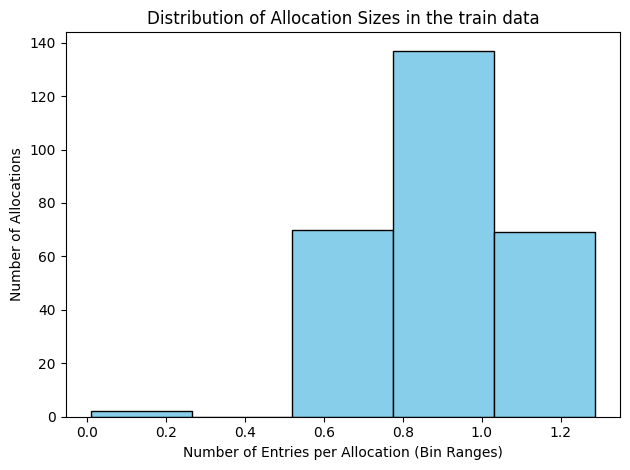

In [ ]:
(alloc_counts_train/alloc_counts_train.mean()).plot(kind='hist', bins=5, edgecolor='black', color='skyblue')

plt.title('Distribution of Allocation Sizes in the train data')
plt.xlabel('Number of Entries per Allocation (Bin Ranges)')
plt.ylabel('Number of Allocations')
plt.tight_layout()

In [ ]:
# Filter the series to find groups with 500 or fewer entries
small_allocs_train = (alloc_counts_train/alloc_counts_train.mean())[(alloc_counts_train/alloc_counts_train.mean()) <= 0.4]

# Display the group names and their exact counts
print(small_allocs_train)

ALLOCATION
ALLOCATION_14    0.010021
ALLOCATION_46    0.010021
Name: count, dtype: float64


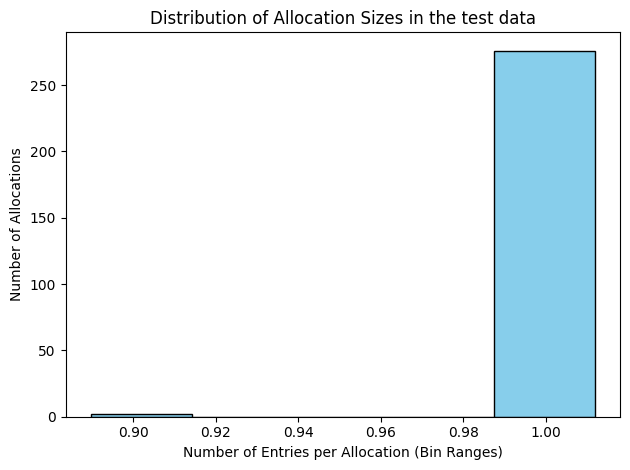

In [ ]:
(alloc_counts_test/(alloc_counts_test.mean())).plot(kind='hist', bins=5, edgecolor='black', color='skyblue')

plt.title('Distribution of Allocation Sizes in the test data')
plt.xlabel('Number of Entries per Allocation (Bin Ranges)')
plt.ylabel('Number of Allocations')
plt.tight_layout()

In [ ]:
# Filter the series to find groups with 500 or fewer entries
small_allocs_test = (alloc_counts_test/(alloc_counts_test.mean()))[(alloc_counts_test/(alloc_counts_test.mean())) <= 0.2]

# Display the group names and their exact counts
print(small_allocs_test)

Series([], Name: count, dtype: float64)


##Distribution of returns

In [ ]:
train_df["MEAN_RET"] = train_df[[f"RET_{i}" for i in range(1,21)]].mean(axis=1)
train_df["RET_STD"] = train_df[[f"RET_{i}" for i in range(1,21)]].std(axis=1)
test_df["MEAN_RET"] = test_df[[f"RET_{i}" for i in range(1,21)]].mean(axis=1)
test_df["RET_STD"] = test_df[[f"RET_{i}" for i in range(1,21)]].std(axis=1)

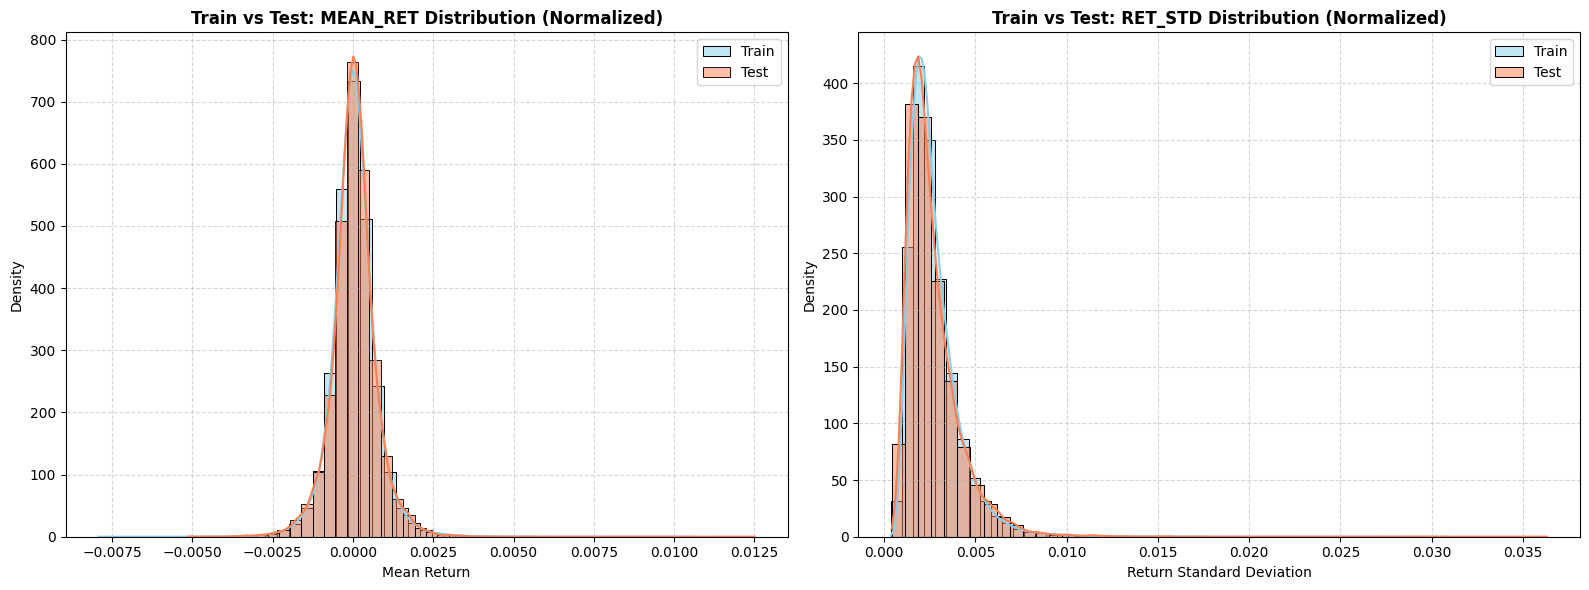

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# --- Plot 1: MEAN_RET (Normalized) ---
# Note the added stat='density' parameter
sns.histplot(train_df['MEAN_RET'], kde=True, bins=50, color='skyblue',
             label='Train', alpha=0.5, stat='density', ax=axes[0])
sns.histplot(test_df['MEAN_RET'], kde=True, bins=50, color='coral',
             label='Test', alpha=0.5, stat='density', ax=axes[0])

axes[0].set_title('Train vs Test: MEAN_RET Distribution (Normalized)', fontsize=12, weight='bold')
axes[0].set_xlabel('Mean Return')
axes[0].set_ylabel('Density')  # Updated label
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- Plot 2: RET_STD (Normalized) ---
sns.histplot(train_df['RET_STD'], kde=True, bins=50, color='skyblue',
             label='Train', alpha=0.5, stat='density', ax=axes[1])
sns.histplot(test_df['RET_STD'], kde=True, bins=50, color='coral',
             label='Test', alpha=0.5, stat='density', ax=axes[1])

axes[1].set_title('Train vs Test: RET_STD Distribution (Normalized)', fontsize=12, weight='bold')
axes[1].set_xlabel('Return Standard Deviation')
axes[1].set_ylabel('Density')  # Updated label
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# 1. Compute profiles for both train and test separately
train_profile = train_df.groupby('ALLOCATION')['MEAN_RET'].agg(['mean', 'std']).reset_index()
train_profile['Dataset'] = 'Train'

test_profile = test_df.groupby('ALLOCATION')['MEAN_RET'].agg(['mean', 'std']).reset_index()
test_profile['Dataset'] = 'Test'

# 2. Concatenate them vertically into a single DataFrame
combined_profile = pd.concat([train_profile, test_profile], ignore_index=True)

# 3. Create the interactive scatter plot
fig = px.scatter(
    combined_profile,
    x='mean',
    y='std',
    color='Dataset',          # Automatically splits colors by Train/Test and adds a legend
    hover_name='ALLOCATION',  # Outlines the Allocation ID at the top of the hover card
    hover_data={'Dataset': True, 'mean': ':.5f', 'std': ':.5f'}, # Includes Dataset & formats decimals
    title='Interactive Allocation Risk-Return Space (Train vs Test)',
    labels={'mean': 'Expected Mean of MEAN_RET', 'std': 'Standard Deviation (Spread)'},
    color_discrete_map={'Train': '#1f77b4', 'Test': '#ff7f0e'} # Explicitly sets nice blue and orange tones
)

# 4. Clean up presentation
fig.update_traces(marker=dict(size=8, opacity=0.7, line=dict(width=0.5, color='White')))

# Optional: Makes the grid lines look a bit cleaner
fig.update_layout(template='plotly_white')

fig.show()

In [ ]:
def compute_ks_anomalies(df, target_col, group_col):
    """
    Compares each group's distribution against the global distribution baseline.
    """
    global_values = df[target_col].values
    ks_results = {}
    ks_pvalues = {}

    for group_id, group in df.groupby(group_col):
        # Calculate the KS statistic (ignoring the p-value for sorting purposes)
        stat, p = ks_2samp(group[target_col].values, global_values)
        ks_results[group_id] = stat
        ks_pvalues[group_id] = p

    return pd.Series(ks_results), ks_pvalues

# 1. Compute the KS statistics independently for Train and Test
train_ks, train_p = compute_ks_anomalies(train_df, 'MEAN_RET', 'ALLOCATION')
test_ks, test_p = compute_ks_anomalies(test_df, 'MEAN_RET', 'ALLOCATION')

# 2. Combine into a single, comprehensive DataFrame
ks_comparison = pd.DataFrame({
    'Train_KS_Stat': train_ks,
    'Test_KS_Stat': test_ks
})

# 3. Add an absolute difference column to quickly find out if
# an allocation behaves radically differently in train vs test
ks_comparison['KS_Diff'] = (ks_comparison['Train_KS_Stat'] - ks_comparison['Test_KS_Stat']).abs()

# --- Display Results ---

print("=== Top 10 Most Anomalous Allocations in TRAIN ===")
print(ks_comparison.sort_values(by='Train_KS_Stat', ascending=False)[['Train_KS_Stat']].head(10))

print("\n=== Top 10 Most Anomalous Allocations in TEST ===")
print(ks_comparison.sort_values(by='Test_KS_Stat', ascending=False)[['Test_KS_Stat']].head(10))

print("\n=== Top 5 Allocations with the Largest Discrepancy Between Train and Test ===")
print(ks_comparison.sort_values(by='KS_Diff', ascending=False).head(15))

=== Top 10 Most Anomalous Allocations in TRAIN ===
                Train_KS_Stat
ALLOCATION_14        0.762305
ALLOCATION_46        0.762305
ALLOCATION_118       0.720556
ALLOCATION_168       0.698240
ALLOCATION_85        0.643300
ALLOCATION_86        0.560711
ALLOCATION_19        0.473445
ALLOCATION_152       0.447574
ALLOCATION_195       0.446445
ALLOCATION_113       0.436378

=== Top 10 Most Anomalous Allocations in TEST ===
                Test_KS_Stat
ALLOCATION_195      0.678901
ALLOCATION_86       0.652433
ALLOCATION_168      0.651660
ALLOCATION_156      0.643019
ALLOCATION_118      0.602703
ALLOCATION_185      0.595407
ALLOCATION_25       0.552842
ALLOCATION_85       0.542780
ALLOCATION_152      0.520475
ALLOCATION_80       0.461426

=== Top 5 Allocations with the Largest Discrepancy Between Train and Test ===
                Train_KS_Stat  Test_KS_Stat   KS_Diff
ALLOCATION_46        0.762305      0.084492  0.677813
ALLOCATION_14        0.762305      0.098825  0.663479
ALLOCATI

##Distribution of missing values

In [ ]:
train_df.isna().mean()

,0
TS,0.000000
ALLOCATION,0.000000
RET_20,0.000110
RET_19,0.000095
RET_18,0.000080
RET_17,0.000065
RET_16,0.000049
RET_15,0.000034
RET_14,0.000025
RET_13,0.000017


In [ ]:
test_df.isna().mean()

,0
ROW_ID,0.000000
TS,0.000000
ALLOCATION,0.000000
RET_20,0.000126
RET_19,0.000126
RET_18,0.000126
RET_17,0.000126
RET_16,0.000126
RET_15,0.000126
RET_14,0.000126


## Distribution of the target

In [ ]:
train_df.groupby("ALLOCATION")["TARGET"].mean()

,TARGET
ALLOCATION,
ALLOCATION_01,-0.000107
ALLOCATION_02,0.000079
ALLOCATION_03,-0.000108
ALLOCATION_04,-0.000044
ALLOCATION_05,0.000021
...,...
ALLOCATION_95,0.000096
ALLOCATION_96,0.000051
ALLOCATION_97,0.000121


In [ ]:
# Aggregate the core statistical moments for each allocation's target
alloc_profile = train_df.groupby("ALLOCATION")["TARGET"].agg(
    sample_count='count',
    mean_target='mean',
    volatility='std',
    skewness='skew',
    kurtosis=pd.Series.kurt  # Tracks fat-tailed risk
).reset_index()

# Sort by mean target to find your highest-alpha groups instantly
alloc_profile = alloc_profile.sort_values(by="mean_target", ascending=False)

In [ ]:
alloc_profile

,ALLOCATION,sample_count,mean_target,volatility,skewness,kurtosis
67,ALLOCATION_152,2439,0.001432,0.003443,0.582420,1.972794
209,ALLOCATION_31,1864,0.001264,0.003086,0.832572,2.385016
105,ALLOCATION_187,1931,0.000852,0.002877,0.597245,4.141467
84,ALLOCATION_168,1931,0.000661,0.003241,0.072268,3.080398
29,ALLOCATION_118,2439,0.000584,0.003734,-0.133656,2.483771
...,...,...,...,...,...,...
264,ALLOCATION_86,1931,-0.000358,0.002792,-0.094664,2.701363
71,ALLOCATION_156,2439,-0.000748,0.003757,-0.624254,1.921964
22,ALLOCATION_111,1864,-0.001203,0.003393,-0.840204,2.712126
53,ALLOCATION_14,19,-0.004346,0.016293,-1.036431,0.974550


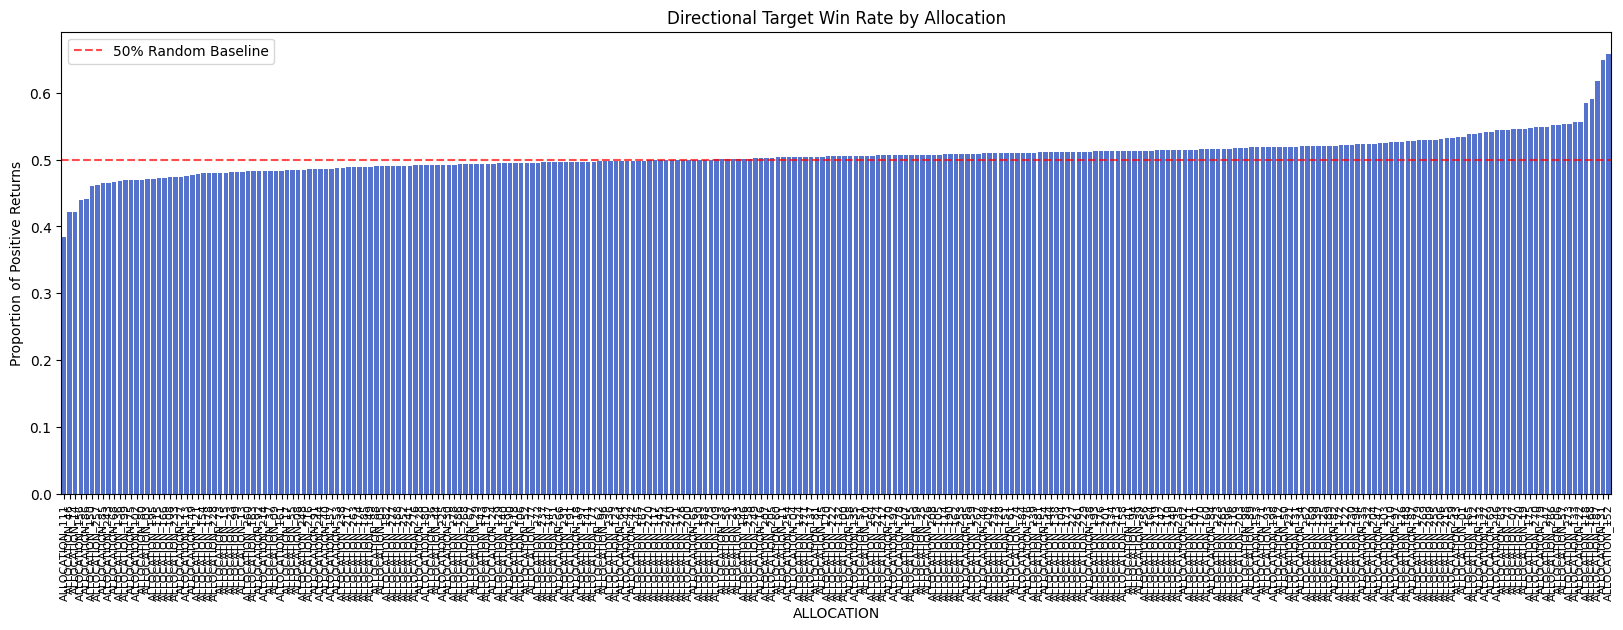

In [ ]:
# Create a binary target indicator mapping positive moves
train_df['is_positive'] = (train_df['TARGET'] > 0).astype(int)

# Calculate target win-rates per group
win_rates = train_df.groupby("ALLOCATION")['is_positive'].mean().sort_values()

# Plot the sorted win rates as a bar chart to see the dispersion
plt.figure(figsize=(20, 6))
sns.barplot(x=win_rates.index, y=win_rates.values, order=win_rates.index, color='royalblue')
plt.axhline(0.5, color='red', linestyle='--', alpha=0.7, label='50% Random Baseline')
plt.xticks(rotation=90, fontsize=8)
plt.title("Directional Target Win Rate by Allocation")
plt.ylabel("Proportion of Positive Returns")
plt.legend()
plt.show()

# Clean up temp column
train_df.drop(columns=['is_positive'], inplace=True)

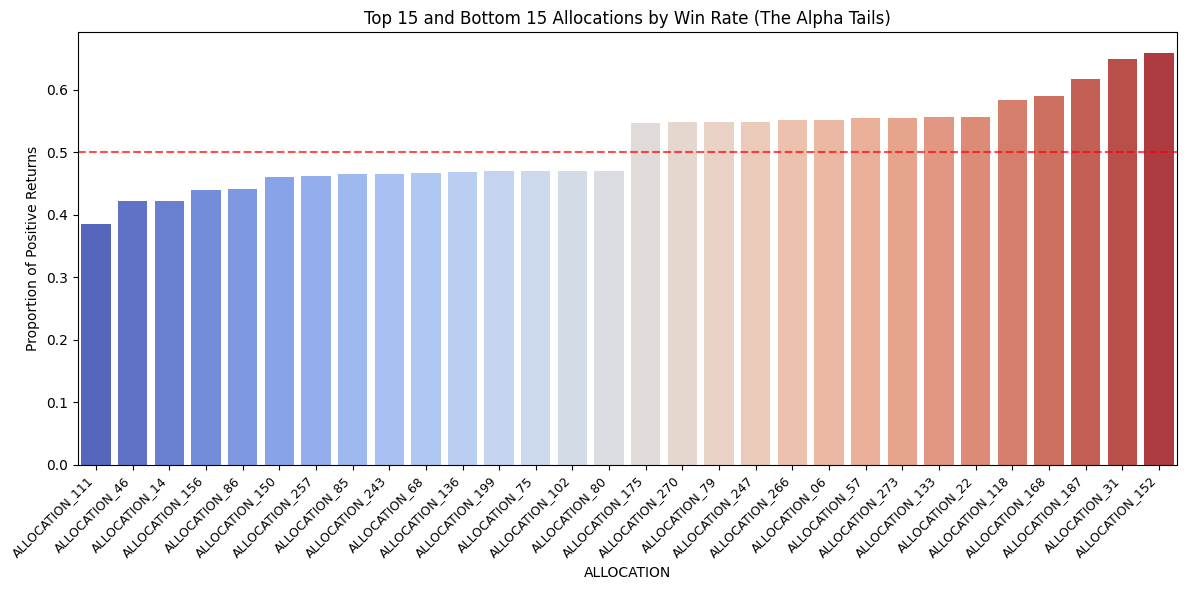

In [ ]:
# Calculate win rates and sort them
df_positive = (train_df['TARGET'] > 0).astype(int)
win_rates = train_df.groupby("ALLOCATION").apply(lambda x: (x['TARGET'] > 0).mean()).sort_values()

# Isolate the tails
tail_allocations = pd.concat([win_rates.head(15), win_rates.tail(15)])

# Plot a clean, spaced-out bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=tail_allocations.index, y=tail_allocations.values, palette="coolwarm")
plt.axhline(0.5, color='red', linestyle='--', alpha=0.7, label='50% Baseline')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.title("Top 15 and Bottom 15 Allocations by Win Rate (The Alpha Tails)")
plt.ylabel("Proportion of Positive Returns")
plt.tight_layout()
plt.show()

In [ ]:
[x for x in top_alloc_features[:10] if x[11:] in ks_list[:10]]

['ALLOCATION_ALLOCATION_156']

['ALLOCATION_ALLOCATION_152',
 'ALLOCATION_ALLOCATION_31',
 'ALLOCATION_ALLOCATION_111',
 'ALLOCATION_ALLOCATION_187',
 'ALLOCATION_ALLOCATION_118',
 'ALLOCATION_ALLOCATION_168',
 'ALLOCATION_ALLOCATION_156',
 'ALLOCATION_ALLOCATION_86',
 'ALLOCATION_ALLOCATION_133',
 'ALLOCATION_ALLOCATION_57',
 'ALLOCATION_ALLOCATION_22',
 'ALLOCATION_ALLOCATION_273',
 'ALLOCATION_ALLOCATION_266',
 'ALLOCATION_ALLOCATION_247',
 'ALLOCATION_ALLOCATION_63',
 'ALLOCATION_ALLOCATION_85',
 'ALLOCATION_ALLOCATION_79',
 'ALLOCATION_ALLOCATION_150',
 'ALLOCATION_ALLOCATION_127',
 'ALLOCATION_ALLOCATION_270']

In [ ]:
ks_list=list(ks_comparison.sort_values(by='KS_Diff', ascending=False).index)

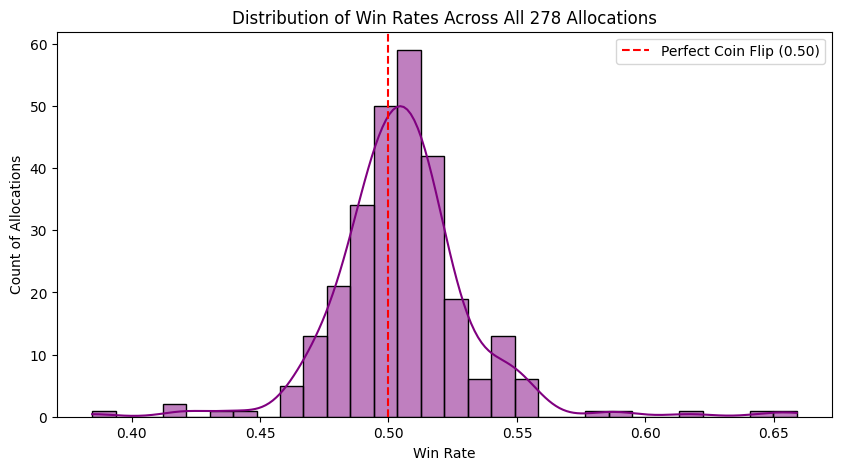

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(win_rates.values, bins=30, kde=True, color='purple')
plt.axvline(0.5, color='red', linestyle='--', label='Perfect Coin Flip (0.50)')
plt.title("Distribution of Win Rates Across All 278 Allocations")
plt.xlabel("Win Rate")
plt.ylabel("Count of Allocations")
plt.legend()
plt.show()

In [ ]:
# Categorize allocations into behavioral buckets
def bucket_win_rate(rate):
    if rate < 0.45: return "Strong Short Signal (<45%)"
    elif rate < 0.49: return "Slight Short Bias (45-49%)"
    elif rate <= 0.51: return "Pure Market Noise (49-51%)"
    elif rate <= 0.55: return "Slight Long Bias (51-55%)"
    else: return "Strong Long Signal (>55%)"

alloc_buckets = win_rates.apply(bucket_win_rate).value_counts()
print("--- Allocation Behavioral Breakdown ---")
print(alloc_buckets)

--- Allocation Behavioral Breakdown ---
Pure Market Noise (49-51%)    114
Slight Long Bias (51-55%)      96
Slight Short Bias (45-49%)     52
Strong Long Signal (>55%)      11
Strong Short Signal (<45%)      5
Name: count, dtype: int64


In [ ]:

# 2. Map each allocation ID to its structural bucket definition
def get_bucket_name(alloc_id):
    rate = win_rates.get(alloc_id, 0.50)
    if rate < 0.45:
        return "Short Expert Bucket (<45% Win Rate)"
    elif rate > 0.55:
        return "Long Expert Bucket (>55% Win Rate)"
    else:
        return "Noise Expert Bucket (45-55% Win Rate)"

# 3. Apply the mapping directly to the row-level training DataFrame
train_df['regime_bucket'] = train_df['ALLOCATION'].map(get_bucket_name)

# 4. Count the total number of rows (observations) in each bucket
bucket_row_counts = train_df['regime_bucket'].value_counts()
bucket_percentage = train_df['regime_bucket'].value_counts(normalize=True) * 100

# 5. Clean display of the volume distribution
print("=== REGIME BUCKET VOLUME DISTRIBUTION ===")
for bucket in bucket_row_counts.index:
    print(f"{bucket}:")
    print(f"  -> Total Rows: {bucket_row_counts[bucket]:,}")
    print(f"  -> % of Dataset: {bucket_percentage[bucket]:.2f}%")
    print("-" * 40)

=== REGIME BUCKET VOLUME DISTRIBUTION ===
Noise Expert Bucket (45-55% Win Rate):
  -> Total Rows: 499,312
  -> % of Dataset: 94.73%
----------------------------------------
Long Expert Bucket (>55% Win Rate):
  -> Total Rows: 21,489
  -> % of Dataset: 4.08%
----------------------------------------
Short Expert Bucket (<45% Win Rate):
  -> Total Rows: 6,272
  -> % of Dataset: 1.19%
----------------------------------------


# Analysis of predictions

In [ ]:
test_diagnostic_df.sort_values(by="final_proba",ascending=False).head()

,row_id,TS,ALLOCATION,lgbm_mean,cat_mean,final_proba,prediction,confidence,margin_from_threshold
20271,20271,DATE_2599,ALLOCATION_152,0.649035,0.636522,0.707110,1,0.207110,0.207110
12353,12353,DATE_2570,ALLOCATION_152,0.649035,0.635779,0.706556,1,0.206556,0.206556
23537,23537,DATE_2612,ALLOCATION_152,0.649035,0.634718,0.706064,1,0.206064,0.206064
29995,29995,DATE_2636,ALLOCATION_152,0.649035,0.629223,0.702670,1,0.202670,0.202670
21105,21105,DATE_2603,ALLOCATION_152,0.649035,0.623850,0.699361,1,0.199361,0.199361


In [ ]:
y_clf = train_diagnostic_df["target"]
oof_probas = train_diagnostic_df["oof_stack"]

In [ ]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_clf, oof_probas, n_bins=10)
print(pd.DataFrame({"pred": prob_pred, "true": prob_true}))

       pred      true
0  0.293645  0.000000
1  0.367066  0.339248
2  0.488148  0.485850
3  0.514550  0.516401
4  0.640173  0.619651
5  0.708129  0.779180


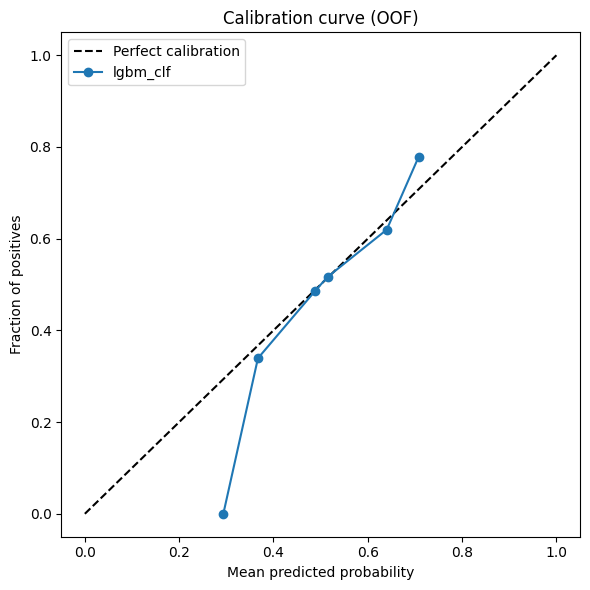

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")


prob_true, prob_pred = calibration_curve(
    y_clf, oof_probas, n_bins=10
)
ax.plot(prob_pred, prob_true, marker="o", label=key)

ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration curve (OOF)")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
train_diagnostic_df.sort_values(by="confidence",ascending=False)

,row_id,target,TS,ALLOCATION,oof_lgbm_mean,oof_cat_mean,oof_stack,pred_lgbm,pred_cat,pred_stack,confidence,margin_from_threshold
242229,242229,1,DATE_1163,ALLOCATION_152,0.652356,0.660741,0.732067,1,1,1,2.320667e-01,2.320667e-01
154059,154059,1,DATE_0742,ALLOCATION_152,0.650022,0.660535,0.729082,1,1,1,2.290820e-01,2.290820e-01
572,572,1,DATE_0003,ALLOCATION_152,0.650118,0.666576,0.728442,1,1,1,2.284419e-01,2.284419e-01
479619,479619,1,DATE_2298,ALLOCATION_152,0.648284,0.658195,0.727784,1,1,1,2.277842e-01,2.277842e-01
244210,244210,1,DATE_1172,ALLOCATION_152,0.650623,0.651104,0.726974,1,1,1,2.269739e-01,2.269739e-01
...,...,...,...,...,...,...,...,...,...,...,...,...
486409,486409,1,DATE_2332,ALLOCATION_181,0.508867,0.494282,0.500000,1,0,1,2.263153e-07,2.263153e-07
323458,323458,0,DATE_1538,ALLOCATION_105,0.505417,0.500475,0.500000,1,1,1,1.744716e-07,1.744716e-07
214512,214512,0,DATE_1031,ALLOCATION_236,0.503264,0.503162,0.500000,1,1,0,5.340796e-08,-5.340796e-08
5968,5968,1,DATE_0031,ALLOCATION_77,0.499974,0.506101,0.500000,0,1,0,4.004091e-08,-4.004091e-08


# Analysis of features

In [ ]:
# -------------------------
# Global configuration
# -------------------------
TARGET = "TARGET_SIGN"                 # target column name

N_GROUPS = None                      # set to None if using THRESHOLD
THRESHOLD = 0.6                 # set to None if using N_GROUPS

CORR_METHOD = "spearman"          # "pearson", "spearman", or "kendall"
LINKAGE_METHOD = "complete"        # better fit for correlation distance than ward
OUTPUT_STEM = "feature_groups"    # base filename for saved plots

In [ ]:

# -------------------------
# Core helpers
# -------------------------
def compute_correlation_bundle(df: pd.DataFrame, features: list[str], target: str, method: str):
    cols = [*features, target]
    corr_full = df[cols].corr(method=method)
    corr_features = corr_full.loc[features, features]
    target_corr = corr_full.loc[features, target]
    return corr_full, corr_features, target_corr


def fast_correlation_matrix(df: pd.DataFrame, cols: list[str], method: str = "pearson") -> pd.DataFrame:
    """
    Fast correlation matrix using NumPy.

    method:
        - "pearson": fast centered matrix multiply
        - "spearman": rank each column first, then Pearson on ranks
    """
    X = df[cols].to_numpy(dtype=np.float32, copy=True)

    # Fast NaN handling: keep only complete rows for the selected columns.
    # This is much faster than pairwise deletion.
    mask = np.isfinite(X).all(axis=1)
    X = X[mask]

    if X.shape[0] < 2:
        raise ValueError("Not enough complete rows to compute correlations.")

    if method == "spearman":
        # Rank each column independently.
        # axis=0 ranks within each feature column.
        X = np.apply_along_axis(rankdata, 0, X).astype(np.float32)

    # Center columns
    X -= X.mean(axis=0, keepdims=True)

    # Sample std dev (ddof=1)
    std = X.std(axis=0, ddof=1, keepdims=True)

    # Avoid division by zero for constant columns
    good = std.squeeze() > 0
    if not np.all(good):
        cols = [c for c, ok in zip(cols, good) if ok]
        X = X[:, good]
        std = std[:, good]

    X /= std

    # Correlation matrix = standardized cross-product / (n - 1)
    corr = (X.T @ X) / (X.shape[0] - 1)
    corr = np.clip(corr, -1.0, 1.0)

    return pd.DataFrame(corr, index=cols, columns=cols)


def build_distance_matrix(corr: pd.DataFrame) -> np.ndarray:
    dist = 1.0 - corr.abs().to_numpy(copy=True)
    np.fill_diagonal(dist, 0.0)
    dist = np.clip(dist, 0.0, None)
    return squareform(dist, checks=False)


def cluster_features(corr: pd.DataFrame, n_groups: int | None = None, threshold: float | None = None):
    if (n_groups is None) == (threshold is None):
        raise ValueError("Provide exactly one of n_groups or threshold.")

    condensed = build_distance_matrix(corr)
    Z = linkage(condensed, method=LINKAGE_METHOD)

    if n_groups is not None:
        labels = fcluster(Z, t=n_groups, criterion="maxclust")
    else:
        labels = fcluster(Z, t=threshold, criterion="distance")

    return labels, Z


def members_by_group(features: list[str], labels: np.ndarray) -> dict[int, list[str]]:
    groups: dict[int, list[str]] = {}
    for feat, grp in zip(features, labels):
        groups.setdefault(int(grp), []).append(feat)
    return groups


def group_target_stats(features: list[str], labels: np.ndarray, corr_features: pd.DataFrame, target_corr: pd.Series):
    rows = []
    groups = members_by_group(features, labels)

    for grp in sorted(groups):
        members = groups[grp]
        sub = corr_features.loc[members, members]
        sub_target = target_corr.loc[members]

        if len(members) > 1:
            vals = sub.to_numpy(copy=False)
            upper = vals[np.triu_indices(len(members), k=1)]
            mean_within = float(np.mean(np.abs(upper))) if upper.size else 1.0
        else:
            mean_within = 1.0

        abs_target = sub_target.abs()
        best_feature = abs_target.idxmax()
        best_corr = float(sub_target.loc[best_feature])

        rows.append(
            {
                "group": grp,
                "size": len(members),
                "mean_within_abs_corr": round(mean_within, 4),
                "mean_abs_target_corr": round(float(abs_target.mean()), 4),
                "best_feature": best_feature,
                "best_corr_to_target": round(best_corr, 4),
                "members": members,
            }
        )

    return (
        pd.DataFrame(rows)
        .sort_values("mean_abs_target_corr", ascending=False)
        .reset_index(drop=True)
    )


def ordered_features_and_labels(features: list[str], labels: np.ndarray):
    ordered = sorted(zip(labels, features), key=lambda x: (int(x[0]), x[1]))
    sorted_labels = [int(g) for g, _ in ordered]
    sorted_features = [f for _, f in ordered]
    return sorted_features, sorted_labels


def group_colours(labels: np.ndarray):
    cmap = plt.get_cmap("tab20")
    groups = sorted(set(int(g) for g in labels))
    return {g: cmap(i % 20) for i, g in enumerate(groups)}


def save_fig(fig, path: str):
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"saved -> {path}")



In [ ]:
# -------------------------
# Plotting
# -------------------------
def plot_heatmap(corr_features: pd.DataFrame, features: list[str], labels: np.ndarray, out_path: str):
    n = len(features)
    sorted_feats, sorted_labels = ordered_features_and_labels(features, labels)
    label_to_colour = group_colours(labels)

    corr_sorted = corr_features.loc[sorted_feats, sorted_feats]

    mask = np.zeros_like(corr_sorted, dtype=bool)
    mask[np.triu_indices_from(mask, k=1)] = True

    side = max(10, n * 0.35)
    fig, ax = plt.subplots(figsize=(side + 2, side))

    sns.heatmap(
        corr_sorted,
        mask=mask,
        ax=ax,
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.2,
        linecolor="white",
        cbar_kws={"shrink": 0.5, "label": "Correlation", "pad": 0.02},
        annot=n <= 30,
        fmt=".2f",
        annot_kws={"size": max(5, min(8, int(200 / max(n, 1))))},
        xticklabels=True,
        yticklabels=True,
    )

    tick_fs = max(4, min(10, int(220 / max(n, 1))))
    ax.tick_params(axis="x", rotation=90, labelsize=tick_fs)
    ax.tick_params(axis="y", rotation=0, labelsize=tick_fs)

    # group boundary lines
    boundaries = []
    prev = None
    for i, g in enumerate(sorted_labels):
        if prev is not None and g != prev:
            boundaries.append(i)
        prev = g

    for b in boundaries:
        ax.axhline(b, color="black", lw=1.5)
        ax.axvline(b, color="black", lw=1.5)

    # label each block on the diagonal
    run_start = 0
    for i in range(1, n + 1):
        if i == n or sorted_labels[i] != sorted_labels[i - 1]:
            g = sorted_labels[i - 1]
            mid = run_start + (i - run_start) / 2
            ax.text(
                mid, mid, f"G{g}",
                ha="center", va="center",
                fontsize=max(7, min(13, int(300 / max(n, 1)))),
                fontweight="bold",
                color=label_to_colour[g],
                alpha=0.85,
            )
            run_start = i

    ax.set_title(
        f"Feature correlation matrix — {n} features, {len(set(labels))} groups\n"
        f"Red = positive, blue = negative. Thick lines = group boundaries. Method = {CORR_METHOD}",
        fontsize=11,
        pad=12,
    )
    save_fig(fig, out_path)


def plot_dendrogram(Z: np.ndarray, features: list[str], labels: np.ndarray, out_path: str):
    n = len(features)
    label_to_colour = group_colours(labels)
    leaf_colours = {f: label_to_colour[int(g)] for f, g in zip(features, labels)}

    fig, ax = plt.subplots(figsize=(14, max(10, n * 0.28)))

    dendrogram(
        Z,
        labels=features,
        orientation="left",
        ax=ax,
        leaf_font_size=max(5, min(9, int(220 / max(n, 1)))),
        color_threshold=0,
        above_threshold_color="#888888",
        no_plot=False,
    )

    for lbl in ax.get_yticklabels():
        feat = lbl.get_text()
        if feat in leaf_colours:
            lbl.set_color(leaf_colours[feat])

    ax.set_title(
        "Hierarchical dendrogram\n"
        "Leaf colour = group. Features merging at low distance are highly correlated.",
        fontsize=11,
        pad=12,
    )
    ax.set_xlabel("Linkage distance (0 = identical, larger = more different)", fontsize=9)
    ax.spines[["top", "right", "left"]].set_visible(False)
    save_fig(fig, out_path)


def plot_group_summary(stats: pd.DataFrame, labels: np.ndarray, target: str, out_path: str):
    n_groups = len(stats)
    label_to_colour = group_colours(labels)

    fig_h = max(8, n_groups * 0.55 + 3)
    fig, (ax_bar, ax_tbl) = plt.subplots(
        1, 2, figsize=(20, fig_h), gridspec_kw={"width_ratios": [1, 1.6]}
    )

    bar_colours = [label_to_colour[int(g)] for g in stats["group"]]
    ylabels = [f"G{g}" for g in stats["group"]]

    bars = ax_bar.barh(
        ylabels,
        stats["mean_abs_target_corr"],
        color=bar_colours,
        edgecolor="white",
        height=0.55,
    )
    ax_bar.invert_yaxis()
    ax_bar.set_xlabel("Mean |corr| to target", fontsize=10)
    ax_bar.set_title(f"Group predictive strength vs '{target}'\n(ranked strongest -> weakest)", fontsize=11, pad=10)
    ax_bar.spines[["top", "right"]].set_visible(False)

    label_fs = max(6, min(9, int(300 / max(n_groups, 1))))
    x_max = float(stats["mean_abs_target_corr"].max()) if n_groups else 0.0
    for bar, (_, row) in zip(bars, stats.iterrows()):
        signed = f"{row['best_corr_to_target']:+.3f}"
        txt = f"  {row['best_feature']} ({signed})  n={row['size']}"
        ax_bar.text(
            bar.get_width() + x_max * 0.02,
            bar.get_y() + bar.get_height() / 2,
            txt,
            va="center",
            fontsize=label_fs,
        )
    ax_bar.set_xlim(0, max(x_max * 1.7, 0.05))
    ax_bar.tick_params(labelsize=label_fs)

    ax_tbl.axis("off")

    def fmt_members(members):
        s = ", ".join(members)
        return s if len(s) <= 60 else s[:57] + "..."

    table_data = [
        [
            f"G{row['group']}",
            row["size"],
            f"{row['mean_within_abs_corr']:.3f}",
            f"{row['mean_abs_target_corr']:.4f}",
            f"{row['best_corr_to_target']:+.3f}",
            fmt_members(row["members"]),
        ]
        for _, row in stats.iterrows()
    ]

    col_labels = ["Group", "Size", "Within\n|corr|", "->Target\n|corr|", "Best\ncorr", "Members"]
    col_widths = [0.07, 0.06, 0.10, 0.12, 0.10, 0.55]

    tbl = ax_tbl.table(
        cellText=table_data,
        colLabels=col_labels,
        colWidths=col_widths,
        cellLoc="left",
        loc="center",
    )
    tbl.auto_set_font_size(False)
    tbl_fs = max(6, min(9, int(300 / max(n_groups, 1))))
    tbl.set_fontsize(tbl_fs)
    tbl.scale(1, max(1.2, 18 / max(n_groups, 1)))

    for j in range(len(col_labels)):
        tbl[0, j].set_facecolor("#dde8f5")
        tbl[0, j].set_text_props(fontweight="bold")
    for i, (_, row) in enumerate(stats.iterrows(), start=1):
        colour = label_to_colour[int(row["group"])]
        tbl[i, 0].set_facecolor((*colour[:3], 0.25))

    ax_tbl.set_title("Full group summary (sorted by target correlation)", fontsize=11, pad=10)
    save_fig(fig, out_path)


def plot_results(
    features: list[str],
    target: str,
    labels: np.ndarray,
    Z: np.ndarray,
    stats: pd.DataFrame,
    corr_features: pd.DataFrame,
    out_path: str = "feature_groups.png",
):
    stem, ext = os.path.splitext(out_path)
    ext = ext or ".png"

    print(f"\nSaving plots for {len(features)} features, {len(set(labels))} groups:")
    plot_heatmap(corr_features, features, labels, stem + "_1_heatmap" + ext)
    plot_dendrogram(Z, features, labels, stem + "_2_dendrogram" + ext)
    plot_group_summary(stats, labels, target, stem + "_3_summary" + ext)


In [ ]:


# -------------------------
# Run it
# -------------------------
df = train_full_feat_df.drop(columns=['TARGET',"ALLOCATION"])

if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' not found in the CSV.")

features = [c for c in df.columns if c != TARGET]
if not features:
    raise ValueError("No feature columns found after excluding the target.")

# --------------------------------------------------
# Fast correlation computation (NumPy instead of pandas)
# --------------------------------------------------
cols = features + [TARGET]

X = df[cols].to_numpy(dtype=np.float32, copy=False)

# For speed, use complete-case rows
mask = np.isfinite(X).all(axis=1)
X = X[mask]

if CORR_METHOD == "spearman":
    from scipy.stats import rankdata
    X = np.apply_along_axis(rankdata, 0, X).astype(np.float32)

# Standardize columns
X -= X.mean(axis=0, keepdims=True)
std = X.std(axis=0, ddof=1, keepdims=True)

# Drop constant columns
good = std.squeeze() > 0
if not np.all(good):
    kept_cols = [c for c, keep in zip(cols, good) if keep]
    X = X[:, good]
    cols = kept_cols
    std = std[:, good]

X /= std

# Correlation matrix
corr = (X.T @ X) / (X.shape[0] - 1)
corr = np.clip(corr, -1.0, 1.0)

corr_full = pd.DataFrame(corr, index=cols, columns=cols)

features = [c for c in cols if c != TARGET]
corr_features = corr_full.loc[features, features]
target_corr = corr_full.loc[features, TARGET]

In [ ]:

# Cluster and summarize
labels, Z = cluster_features(corr_features, n_groups=N_GROUPS, threshold=THRESHOLD)
stats = group_target_stats(features, labels, corr_features, target_corr)



In [ ]:
len(labels)

186

In [ ]:


# Save plots
plot_results(
    features=features,
    target=TARGET,
    labels=labels,
    Z=Z,
    stats=stats,
    corr_features=corr_features,
    out_path=f"{OUTPUT_STEM}.png",
)

In [ ]:
files.download("feature_groups_3_summary.png")
files.download("feature_groups_2_dendrogram.png")
files.download("feature_groups_1_heatmap.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
stats.shape

(35, 7)

In [ ]:
stats.head(10)

,group,size,mean_within_abs_corr,mean_abs_target_corr,best_feature,best_corr_to_target,members
0,13,11,0.8669,0.0400,alloc_win_rate,0.0450,"[alloc_win_rate, alloc_mean_ret, alloc_sharpe,..."
1,14,1,1.0000,0.0369,regime_bucket,0.0369,[regime_bucket]
2,9,15,0.8283,0.0195,ret_sharpe_ts_z,0.0224,"[ret_rsi, ret_mean, ret_sharpe, ret_pct_pos, r..."
3,15,3,0.9796,0.0160,mdt,0.0161,"[mdt, mdt_ts_z, mdt_ts_rank]"
4,16,1,1.0000,0.0119,vol1_missing,-0.0119,[vol1_missing]
5,33,2,0.7637,0.0118,mkt_avg_perf_3,0.0131,"[mkt_avg_perf_3, mkt_avg_perf_5]"
6,8,6,0.7814,0.0105,ret_last10_ts_z,0.0139,"[ret_last5, ret_last10, ret_last5_ts_z, ret_la..."
7,25,3,0.6149,0.0100,ret_streak5_ts_z,0.0115,"[ret_streak5, ret_streak5_ts_z, ret_streak5_ts..."
8,34,3,0.7766,0.0092,mkt_avg_perf_10,0.0132,"[mkt_avg_perf_10, mkt_avg_perf_15, mkt_avg_per..."
9,31,35,0.7831,0.0080,vol_min_ts_z,-0.0100,"[vol_rsi, vol_mean, vol_min, vol_sharpe, vol_p..."


In [ ]:
selected_cols = []
for _, row in stats.iterrows():
    selected_cols+=row["members"][:1]

In [ ]:
len(stats_sorted)

35

In [ ]:
stats_sorted = stats.sort_values("mean_abs_target_corr", ascending=False).reset_index(drop=True)

bin_1 = []
bin_2 = []

top_n = 3
low_n = 1
high_rank_cutoff = 8

for i, row in stats_sorted.iterrows():
    take_n = top_n if i < high_rank_cutoff else low_n
    chosen = row["members"][:take_n]

    if i <= len(stats_sorted)//2:
        bin_1.extend(chosen)
    else:
        bin_2.extend(chosen)

print("Bin 1:", bin_1)
print("Bin 2:", bin_2)

Bin 1: ['alloc_win_rate', 'alloc_mean_ret', 'alloc_sharpe', 'regime_bucket', 'ret_rsi', 'ret_mean', 'ret_sharpe', 'mdt', 'mdt_ts_z', 'mdt_ts_rank', 'vol1_missing', 'mkt_avg_perf_3', 'mkt_avg_perf_5', 'ret_last5', 'ret_last10', 'ret_last5_ts_z', 'ret_streak5', 'ret_streak5_ts_z', 'ret_streak5_ts_rank', 'mkt_avg_perf_10', 'vol_rsi', 'ret_std', 'vol_std', 'alloc_kurt', 'GROUP_1', 'ret_last1', 'alloc_avg_row_kurt', 'ret_min', 'alloc_avg_row_skew']
Bin 2: ['ret_first5', 'ret_kurt', 'vol_max', 'GROUP_2', 'vol_autocorr1', 'vol_kurt', 'ret_mean_x_vol_mean', 'ret_autocorr1', 'mkt_avg_std', 'ret_vol_corr', 'vol_mom_3_10', 'vol_mom_5_20', 'vol_vol_ratio', 'GROUP_4', 'alloc_skew', 'ret_vol_ratio', 'ret_skew']
